<div style="background-color:#f5f5f5; padding:20px; border-radius:10px;">

<h2>Question 1: Top 5 Products by Sales in 2022</h2>

<p><strong>Scenario:</strong></p>

<p>
The Marketing Team is preparing for a Year-End Festival and needs to identify the top 5 products 
in the <strong>"Mobiles & Tablets"</strong> category that had the highest sales quantities in 2022.
</p>

<p><strong>Requirements:</strong></p>

<ul>
<li>Filter data for <strong>Mobiles & Tablets</strong> category in 2022</li>
<li>Include only valid orders (<strong>is_valid = 1</strong>)</li>
<li>Group by <strong>sku_name</strong> and <strong>category</strong></li>
<li>Calculate total quantity sold</li>
<li>Rank products in descending order</li>
<li>Display top 5 products</li>
<li>Visualize using a horizontal bar chart</li>
</ul>

</div>

In [6]:
import os
import pymysql
import pandas as pd

In [7]:
db_config = {
    "host": "localhost", 
    "user": "root",       
    "password": "baigan",  
    "database": "sales"  
}

In [8]:
output_folder = r"C:\Users\syedm\OneDrive\Desktop\DataNigga" 
os.makedirs(output_folder, exist_ok=True)

In [9]:
tables = ["order_detail", "sku_detail", "payment_detail","customer_detail"]

In [10]:
try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")

    for table in tables:
        print(f"Exporting table: {table}")
        
       
        query = f"SELECT * FROM {table};"
        
    
        df = pd.read_sql(query, connection)
        
       
        output_file = os.path.join(output_folder, f"{table}.csv")
        df.to_csv(output_file, index=False)
        
        print(f"Table {table} exported successfully to {output_file}.")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Database connection successful!
Exporting table: order_detail


C:\Users\syedm\AppData\Local\Temp\ipykernel_9904\1938643473.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Table order_detail exported successfully to C:\Users\syedm\OneDrive\Desktop\DataNigga\order_detail.csv.
Exporting table: sku_detail
Table sku_detail exported successfully to C:\Users\syedm\OneDrive\Desktop\DataNigga\sku_detail.csv.
Exporting table: payment_detail
Table payment_detail exported successfully to C:\Users\syedm\OneDrive\Desktop\DataNigga\payment_detail.csv.
Exporting table: customer_detail
Table customer_detail exported successfully to C:\Users\syedm\OneDrive\Desktop\DataNigga\customer_detail.csv.
Database connection closed.


In [11]:


try:
    connection = pymysql.connect(**db_config)
    print("Tin tin Bhai SQL Connected")

  
    query = """
    SELECT  
        skudet.sku_name AS ProductName,
        skudet.category,
        SUM(ordet.qty_ordered) AS TotalQuantityOrdered
    FROM order_detail AS ordet
    JOIN sku_detail AS skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Mobiles & Tablets'
        AND YEAR(ordet.order_date) = 2022
    GROUP BY 
        skudet.sku_name, skudet.category
    ORDER BY 
        TotalQuantityOrdered DESC
    LIMIT 5;
    """

   
    df = pd.read_sql(query, connection)

    
    output_file = os.path.join(output_folder, "top_5_products.csv")
    df.to_csv(output_file, index=False)

    print(f"Query result exported to {output_file}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Tin tin Yaser Bhai SQL Connected
Query result exported to C:\Users\syedm\OneDrive\Desktop\DataNigga\top_5_products.csv
Database connection closed.


C:\Users\syedm\AppData\Local\Temp\ipykernel_9904\2469815767.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


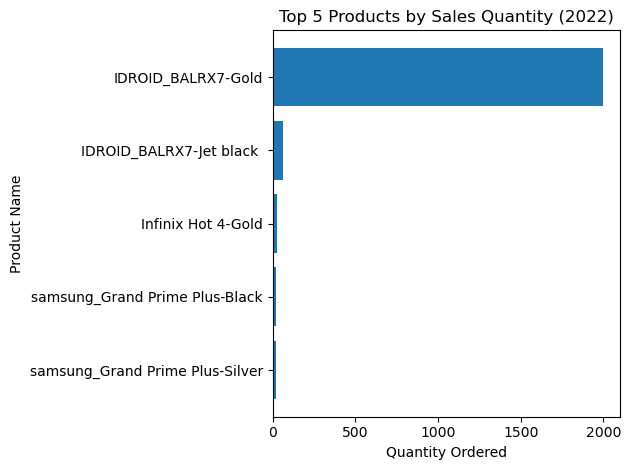

In [12]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by="TotalQuantityOrdered")


plt.figure()
plt.barh(df_sorted["ProductName"], df_sorted["TotalQuantityOrdered"])

plt.xlabel("Quantity Ordered")
plt.ylabel("Product Name")
plt.title("Top 5 Products by Sales Quantity (2022)")

plt.tight_layout()


plt.show()